In [ ]:
import pandas as pd
import seaborn as sns


In [ ]:
data=pd.read_csv("/content/insurance.csv")

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


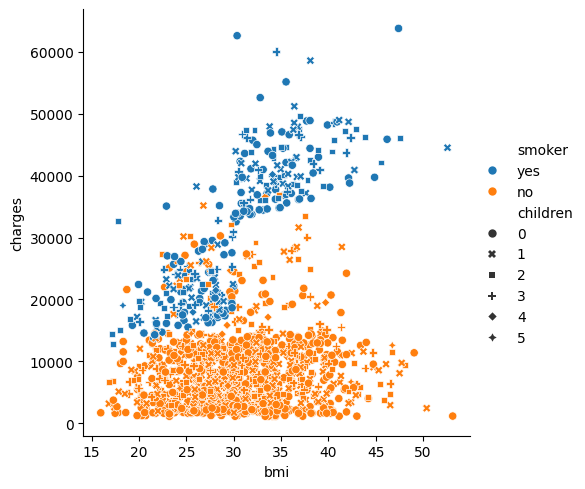

In [ ]:
sns.relplot(x="bmi",y="charges",data=data,kind="scatter",hue="smoker",style="children")

#SPLITTING DATA INTO X AND Y

In [ ]:
X=data.drop(columns=["charges","region"])
y=data["charges"]


Encoding categorical values

In [ ]:
X["sex"]=X["sex"].map({"male":1,"female":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

In [ ]:
X.head()

,age,sex,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0


#Train test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_test.head()

,age,sex,bmi,children,smoker
764,45,0,25.175,2,0
887,36,0,30.020,0,0
890,64,0,26.885,0,1
1293,46,1,25.745,3,0
259,19,1,31.920,0,1


#Training the model

In [ ]:
from sklearn.linear_model import LinearRegression
model =LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [ ]:
y_test

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180
...,...
109,47055.53210
575,12222.89830
535,6067.12675
543,63770.42801


# Evaluation Metrics

In [ ]:
#Evaluation Metrics are used to find how good a model is
#Mean squared error
#Mean Absolute Error
#Root mean squared error
#but for linear regression we use
#R2 score and adjusted r2

In [ ]:
#R@ score is calculated for testing data
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R_Squared: ",r2)

R_Squared:  0.7811302113434095


In [ ]:
#adjusted r2 score is calculated for training data
n= X_test.shape[0]
p= X_test.shape[1]
adjusted_r2= 1-(1-r2)*(n-1)/(n-p-1)
print("Adjusted R_Squared: ",adjusted_r2)

Adjusted R_Squared:  0.7769533069797342


#Feature Engineering
1- Encoding categorical values

In [ ]:
#1- Encoding Categorical values
#One hot encoding
X=data.drop(columns=["charges"])
y=data["charges"]
X["sex"]=X["sex"].map({"male":1,"female":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)




In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
print("R_Squared: ",r2)


R_Squared:  0.7835929767120723


In [ ]:
#Now due to on hot encoding the r2 score has significanty increased

In [ ]:
X_test.head(10)
#Region column has been removed due to drop first =True


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
764,45,0,25.175,2,0,0,0,0
887,36,0,30.020,0,0,1,0,0
890,64,0,26.885,0,1,1,0,0
1293,46,1,25.745,3,0,1,0,0
259,19,1,31.920,0,1,1,0,0
1312,34,1,42.900,1,0,0,0,1
899,19,0,22.515,0,0,1,0,0
752,64,1,37.905,0,0,1,0,0
1286,28,0,17.290,0,0,0,0,0
707,49,1,28.690,3,0,1,0,0


Interaction Features

In [ ]:
X=data.drop(columns=["charges"])
y=data["charges"]
X["sex"]=X["sex"].map({"male":1,"female":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)

X["age_smoker"]=X["age"]* X["smoker"]
X["bmi_smoker"]=X["bmi"]* X["smoker"]

In [ ]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,0,27.900,0,1,0,0,1,19,27.9
1,18,1,33.770,1,0,0,1,0,0,0.0
2,28,1,33.000,3,0,0,1,0,0,0.0
3,33,1,22.705,0,0,1,0,0,0,0.0
4,32,1,28.880,0,0,1,0,0,0,0.0


In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
print("R_Squared: ",r2)

R_Squared:  0.865231697953168


3- Scaling Numeric Features


4- Feature Selection


5- Create useful derived features